<a href="https://colab.research.google.com/github/LuisMesa10/DeepLearning/blob/main/RETO_3_AUTOENCODER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Librerías principales para el modelo de aprendizaje profundo
import tensorflow as tf          # Para construir y entrenar la red neuronal
import numpy as np              # Para manejo de datos numéricos
import matplotlib.pyplot as plt # Para visualizar imágenes y resultados
import os                       # Para manejar rutas de archivos

# Parámetros del modelo
IMG_SIZE = 256   # Tamaño al que se redimensionan las imágenes (256x256)
BATCH_SIZE = 2   # Número de imágenes procesadas en cada paso de entrenamiento (pequeño por memoria)
EPOCHS = 30    # Número de veces que el modelo recorre el dataset completo

In [3]:
def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return mse + 0.5 * ssim

In [4]:
# Función para cargar imágenes usando OpenCV
def load_image_cv2(noisy_path, clean_path):
    import cv2  # Se importa aquí porque tf.py_function lo necesita en su contexto

    # Convertir rutas de tensor a string
    noisy_path = noisy_path.numpy().decode('utf-8')
    clean_path = clean_path.numpy().decode('utf-8')

    # Leer imagen ruidosa en escala de grises
    noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
    noisy = cv2.resize(noisy, (IMG_SIZE, IMG_SIZE))  # Redimensionar
    noisy = noisy.astype(np.float32) / 255.0         # Normalizar [0,1]
    noisy = np.expand_dims(noisy, axis=-1)           # Añadir canal

    # Leer imagen limpia (ground truth)
    clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)
    clean = cv2.resize(clean, (IMG_SIZE, IMG_SIZE))
    clean = clean.astype(np.float32) / 255.0
    clean = np.expand_dims(clean, axis=-1)

    return noisy, clean

    # Función que conecta OpenCV con TensorFlow
def parse_function(noisy_path, clean_path):
    noisy, clean = tf.py_function(
        load_image_cv2,                 # Función que carga imágenes
        [noisy_path, clean_path],       # Entradas
        [tf.float32, tf.float32]        # Tipos de salida
    )

    # Definir tamaño fijo (importante para el modelo)
    noisy.set_shape([IMG_SIZE, IMG_SIZE, 1])
    clean.set_shape([IMG_SIZE, IMG_SIZE, 1])

    return noisy, clean

    # Función para crear el dataset completo
def create_dataset(noisy_dir, clean_dir):
    noisy_files = sorted(os.listdir(noisy_dir))
    clean_files = sorted(os.listdir(clean_dir))

    noisy_paths = [os.path.join(noisy_dir, f) for f in noisy_files]
    clean_paths = [os.path.join(clean_dir, f) for f in clean_files]

    dataset = tf.data.Dataset.from_tensor_slices((noisy_paths, clean_paths))

    dataset = dataset.map(parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(500)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset

In [5]:
# Conectar Google Drive para acceder al dataset
from google.colab import drive
drive.mount('/content/drive')

# Crear dataset de entrenamiento (imágenes ruidosas y ground truth)
train_ds = create_dataset(
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/Noisy",
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/GTruth"
)

# Crear dataset de validación
val_ds = create_dataset(
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/Noisy_val",
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/GTruth_val"
)

train_ds = train_ds.take(300)  # 🔥 MÁS DATOS

Mounted at /content/drive


In [6]:
from tensorflow.keras import layers, models

# Función para construir el autoencoder
def build_autoencoder():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)

    # Bottleneck
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)

    # Decoder
    x = layers.Conv2DTranspose(128, 3, strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)

    outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss=combined_loss)

    return model

# Crear el autoencoder
autoencoder = build_autoencoder()

# Mostrar estructura del modelo
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 128, 128, 128)  │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 256, 256, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 1)    │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,073 (2.82 MB)

 Trainable params: 739,073 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Entrenamiento del autoencoder
history_ae = autoencoder.fit(
    train_ds,            # Datos de entrenamiento (imágenes ruidosas y limpias)
    validation_data=val_ds,  # Datos de validación para evaluar el modelo
    epochs=EPOCHS        # Número de iteraciones completas sobre el dataset
)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 586s 1s/step - loss: 0.1803 - val_loss: 0.2062
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - loss: 0.1467 - val_loss: 0.1867
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - loss: 0.1354 - val_loss: 0.1777
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - loss: 0.1341 - val_loss: 0.1744
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - loss: 0.1298 - val_loss: 0.1653
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - loss: 0.1317 - val_loss: 0.1674
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - loss: 0.1258 - val_loss: 0.1664
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - loss: 0.1250 - val_loss: 0.1709
Epoch 9/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - loss: 0.1220 - val_loss: 0.1639
Epoch 10/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - loss: 0.1241 - val_loss: 0.1530
Epoch 11/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - loss: 0.1217 - val_loss: 0.1623
Epoch 12/30
300/300 ━━━━━━━━━━━

In [8]:
# Función para calcular métricas de calidad de imagen
def compute_metrics(y_true, y_pred):
    # PSNR: mide la calidad de reconstrucción (más alto = mejor)
    psnr = tf.image.psnr(y_true, y_pred, max_val=1.0)

    # SSIM: mide similitud estructural (más cercano a 1 = mejor)
    ssim = tf.image.ssim(y_true, y_pred, max_val=1.0)

    # Promedio de las métricas
    return psnr.numpy().mean(), ssim.numpy().mean()


# Función para calcular ENL (Equivalent Number of Looks)
def enl(image):
    mean = np.mean(image)   # Promedio de la imagen
    var = np.var(image)     # Varianza

    # ENL: mide nivel de ruido (más alto = menos speckle)
    return (mean**2) / var

In [9]:
# Tomar un batch del conjunto de validación
for noisy, clean in val_ds.take(1):
    preds_ae = autoencoder.predict(noisy)  # Predicción del autoencoder

# Calcular métricas entre la imagen real y la reconstruida
psnr_ae, ssim_ae = compute_metrics(clean, preds_ae)

# Mostrar resultados
print("AE → PSNR:", psnr_ae)
print("AE → SSIM:", ssim_ae)
print("AE → ENL:", enl(preds_ae[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
AE → PSNR: 24.867352
AE → SSIM: 0.7217245
AE → ENL: 26.151403


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


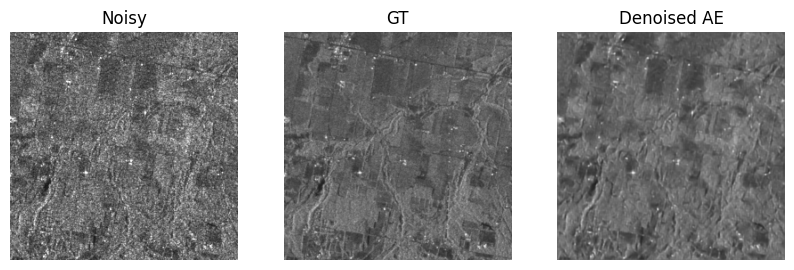

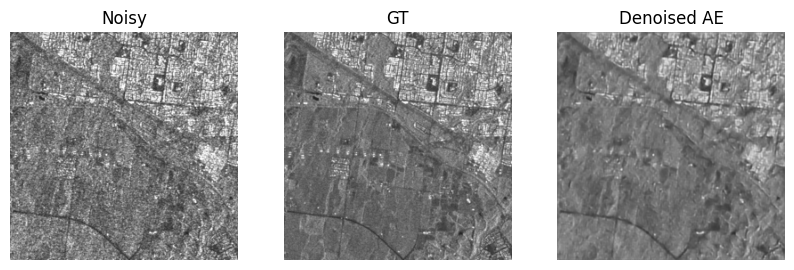

In [10]:

for noisy, clean in val_ds.take(1):
    preds = autoencoder.predict(noisy)

for i in range(len(noisy)):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(noisy[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(clean[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title("GT")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(preds[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title("Denoised AE")
    plt.axis('off')

    plt.show()

In [11]:
# Construcción del modelo U-Net
def build_unet():
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)  # 🔥 extra
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss=combined_loss)

    return model

# Crear modelo U-Net
unet = build_unet()

# Mostrar estructura
unet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 256,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 256, 256,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 256, 256,  │         33 │ conv2d_10[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 277,217 (1.06 MB)

 Trainable params: 277,217 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Entrenamiento del modelo U-Net
history_unet = unet.fit(
    train_ds,             # Datos de entrenamiento (noisy → clean)
    validation_data=val_ds,  # Datos de validación para evaluar desempeño
    epochs=EPOCHS         # Número de épocas
)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - loss: 0.1373 - val_loss: 0.1425
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - loss: 0.1141 - val_loss: 0.1397
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - loss: 0.1090 - val_loss: 0.1318
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - loss: 0.1083 - val_loss: 0.1378
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - loss: 0.1110 - val_loss: 0.1455
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - loss: 0.1103 - val_loss: 0.1339
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - loss: 0.1095 - val_loss: 0.1403
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - loss: 0.1060 - val_loss: 0.1315
Epoch 9/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - loss: 0.1093 - val_loss: 0.1282
Epoch 10/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - loss: 0.1086 - val_loss: 0.1312
Epoch 11/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - loss: 0.1086 - val_loss: 0.1301
Epoch 12/30
300/300 ━━━━━━━━━━

In [13]:
# Tomar un batch del conjunto de validación
for noisy, clean in val_ds.take(1):
    preds_unet = unet.predict(noisy)  # Predicción del U-Net

# Calcular métricas
psnr_unet, ssim_unet = compute_metrics(clean, preds_unet)

# Mostrar resultados
print("U-Net → PSNR:", psnr_unet)
print("U-Net → SSIM:", ssim_unet)
print("U-Net → ENL:", enl(preds_unet[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
U-Net → PSNR: 24.33147
U-Net → SSIM: 0.7338351
U-Net → ENL: 16.987568


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


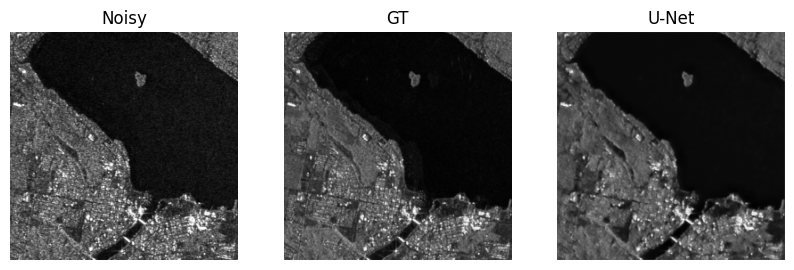

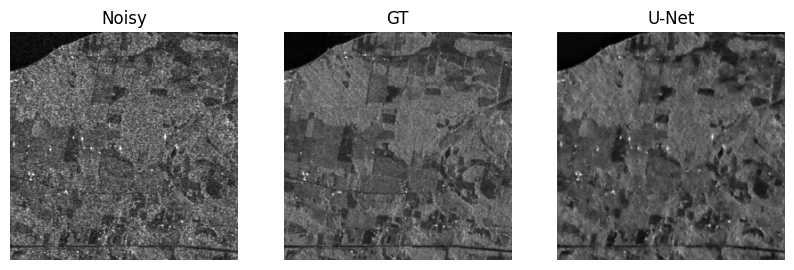

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


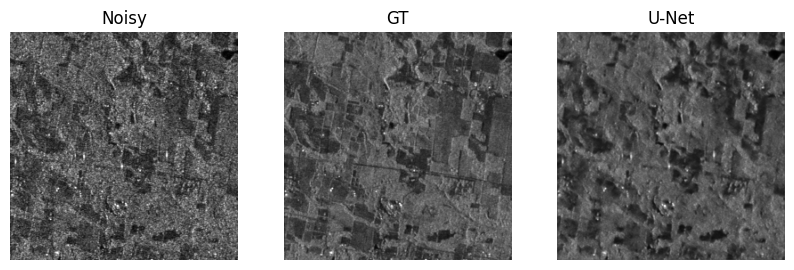

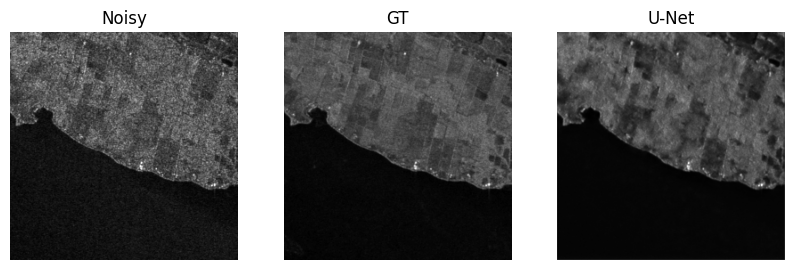

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


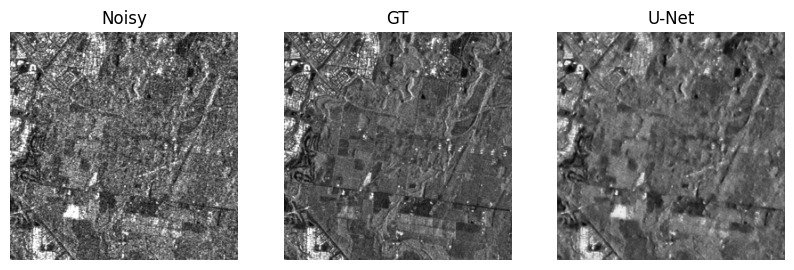

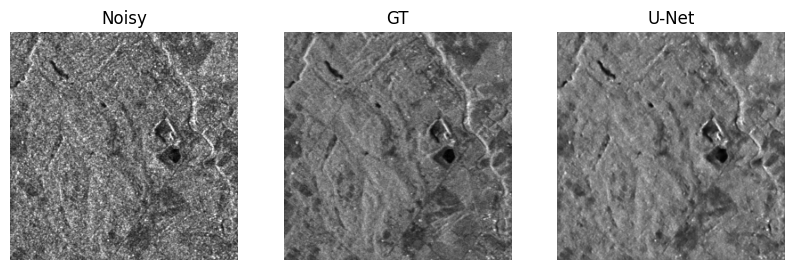

In [14]:
# Visualizar varias imágenes del conjunto de validación
for noisy, clean in val_ds.take(3):  # Tomar 3 batches
    preds = unet.predict(noisy)      # Predicción del modelo

    for i in range(len(noisy)):  # Recorrer imágenes del batch
        plt.figure(figsize=(10,3))

        # Imagen ruidosa (entrada)
        plt.subplot(1,3,1)
        plt.imshow(noisy[i].numpy().squeeze(), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        # Imagen original (ground truth)
        plt.subplot(1,3,2)
        plt.imshow(clean[i].numpy().squeeze(), cmap='gray')
        plt.title("GT")
        plt.axis('off')

        # Imagen reconstruida por U-Net
        plt.subplot(1,3,3)
        plt.imshow(preds[i].squeeze(), cmap='gray')
        plt.title("U-Net")
        plt.axis('off')

        plt.show()

In [15]:
# Mostrar resultados finales de ambos modelos
print("\n--- RESULTADOS ---")

# Métricas del autoencoder
print("Autoencoder → PSNR:", psnr_ae, "| SSIM:", ssim_ae)

# Métricas del U-Net
print("U-Net       → PSNR:", psnr_unet, "| SSIM:", ssim_unet)


--- RESULTADOS ---
Autoencoder → PSNR: 24.867352 | SSIM: 0.7217245
U-Net       → PSNR: 24.33147 | SSIM: 0.7338351
